In [1]:
import quantstream as qs
import os
import xarray as xr
import warnings

warnings.filterwarnings("ignore")

## Introduction

Im this notebook, we'll demonstrate some of the most common techniques used to preprocess financial timeseries data. I'd recomend checking out the following resources for more information on the topic:

- [Python for Finance, 2nd Edition](https://learning.oreilly.com/library/view/python-for-finance/9781492024323/) by Yves Hilpisch

In [7]:
ds_intra = qs.timeseries.get_daily(
    symbol="AAPL",
    from_date="2024-10-01",
    to_date="2024-10-31",
)
ds_intra.to_dataframe().head()

,open,high,low,close,adjClose,volume,unadjustedVolume,change,changePercent,vwap,label,changeOverTime
time,,,,,,,,,,,,
2024-10-31,229.34,229.83,225.37,225.91,225.66,64370100,64370100,-3.43,-1.500000,227.6125,"October 31, 24",-0.015000
2024-10-30,232.61,233.47,229.55,230.10,229.85,47070907,47070907,-2.51,-1.080000,231.4325,"October 30, 24",-0.010800
2024-10-29,233.10,234.33,232.32,233.67,233.41,35417247,35417247,0.57,0.244530,233.3550,"October 29, 24",0.002445
2024-10-28,233.32,234.73,232.55,233.40,233.14,36087134,36087134,0.08,0.034288,233.5000,"October 28, 24",0.000343
2024-10-25,229.74,233.22,229.57,231.41,231.16,38802304,38802304,1.67,0.726910,230.9850,"October 25, 24",0.007269


### Returns and Log Returns

The most common way to preprocess financial timeseries data is to calculate the returns. The return is defined as the percentage change in the price of an asset from one period to the next. The return is calculated as follows:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Where $P_t$ is the price of the asset at time $t$. The log return is defined as the natural logarithm of the return:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

The log return is often preferred over the simple return because it is additive. That is, the log return of a series of returns is equal to the sum of the log returns of the individual returns. This property makes the log return easier to work with in many cases.

In [10]:
df_intra = ds_intra.to_dataframe()
df_intra["return"] = df_intra["adjClose"].pct_change()

<Axes: xlabel='time'>

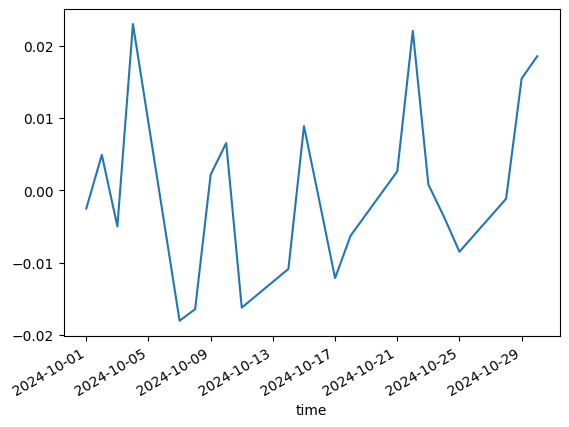

In [11]:
df_intra["return"].plot()

In [12]:
df_intra

,open,high,low,close,adjClose,volume,unadjustedVolume,change,changePercent,vwap,label,changeOverTime,return
time,,,,,,,,,,,,,
2024-10-31,229.34,229.83,225.37,225.91,225.66,64370100,64370100,-3.43,-1.500000,227.6125,"October 31, 24",-0.015000,NaN
2024-10-30,232.61,233.47,229.55,230.10,229.85,47070907,47070907,-2.51,-1.080000,231.4325,"October 30, 24",-0.010800,0.018568
2024-10-29,233.10,234.33,232.32,233.67,233.41,35417247,35417247,0.57,0.244530,233.3550,"October 29, 24",0.002445,0.015488
2024-10-28,233.32,234.73,232.55,233.40,233.14,36087134,36087134,0.08,0.034288,233.5000,"October 28, 24",0.000343,-0.001157
2024-10-25,229.74,233.22,229.57,231.41,231.16,38802304,38802304,1.67,0.726910,230.9850,"October 25, 24",0.007269,-0.008493
2024-10-24,229.98,230.82,228.41,230.57,230.32,31109503,31109503,0.59,0.256540,229.9450,"October 24, 24",0.002565,-0.003634
2024-10-23,234.08,235.14,227.76,230.76,230.51,52287000,52287000,-3.32,-1.420000,231.9350,"October 23, 24",-0.014200,0.000825
2024-10-22,233.89,236.22,232.60,235.86,235.60,38846600,38846600,1.98,0.842280,234.6425,"October 22, 24",0.008423,0.022081
2024-10-21,234.45,236.85,234.45,236.48,236.22,36254500,36254500,2.03,0.865860,235.5575,"October 21, 24",0.008659,0.002632
